# Lab: Regression Analysis

In this lab you will build a regression model step by step and evaluate how well it fits your data.

**Before you start:** run the flowchart below to find out which track to follow.

---
**Throughout this lab:**
- 📌 **Example** — follow along with the provided dataset
- 🎯 **Your Turn** — repeat the steps with your own dataset

## Which track should I follow?

Look at your target variable (the column you are trying to predict) and answer this question:

**Is your target variable numeric and continuous** (e.g. price, temperature, a test score)?  
→ Go to **[🟢 Track A — Linear Regression](#🟢-TRACK-A-—-Linear-Regression)**

**Is your target variable categorical** (e.g. yes/no, species, rating label)?  
→ Go to **[🟠 Track B — Logistic Regression](#🟠-TRACK-B-—-Logistic-Regression)**  
&nbsp;&nbsp;&nbsp;&nbsp;*(works for both 2 categories and 3 or more — same code either way)*

---

| Step | Track A — Linear Regression | Track B — Logistic Regression |
|---|---|---|
| Problem 1 | Load & explore — summary stats | Load & explore — class counts |
| Problem 2 | Scatter plot | Box plot by class |
| Problem 3 | Fit model → slope & intercept | Fit model → coefficients per class |
| Problem 4 | Regression line + R² | Confusion matrix + Accuracy |
| Problem 5 | Residual plot | Predicted probability plot |

---
## Setup

Run this cell first — it imports everything both tracks need.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

---
---
# 🟢 TRACK A — Linear Regression
### *Follow this track if your target variable is numeric and continuous.*
---
---

## A — Problem 1: Load & Explore Your Data

Before fitting any model, understand what your data looks like — its shape, summary statistics, and any obvious issues.

---
### 📌 Example

In [ ]:
# Load the tips dataset
# I am loading the datset
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [49]:
print('Shape:', tips.shape)
print()
tips[['total_bill', 'tip']].describe()

Shape: (244, 7)



,total_bill,tip
count,244.000000,244.000000
mean,19.785943,2.998279
std,8.902412,1.383638
min,3.070000,1.000000
25%,13.347500,2.000000
50%,17.795000,2.900000
75%,24.127500,3.562500
max,50.810000,10.000000


We have **244 rows** and we'll use:
- **X (independent):** `total_bill` — total bill amount
- **y (dependent):** `tip` — tip left by the customer

---
### 🎯 Your Turn

In [50]:
# Load your dataset
# df = pd.read_csv('your_file.csv')

# YOUR CODE HERE


# Preview the first few rows


# Print shape and summary stats for your X and y columns


**Answer these questions:**
1. How many rows does your dataset have?
2. What is your X variable? What does it represent?
3. What is your y variable? What does it represent?
4. Are there any missing values to handle?

*Your answers here:*

1. 
2. 
3. 
4. 

---
## A — Problem 2: Visualize the Relationship

A scatter plot lets us see whether a linear relationship exists *before* fitting any model. Never skip this step.

---
### 📌 Example

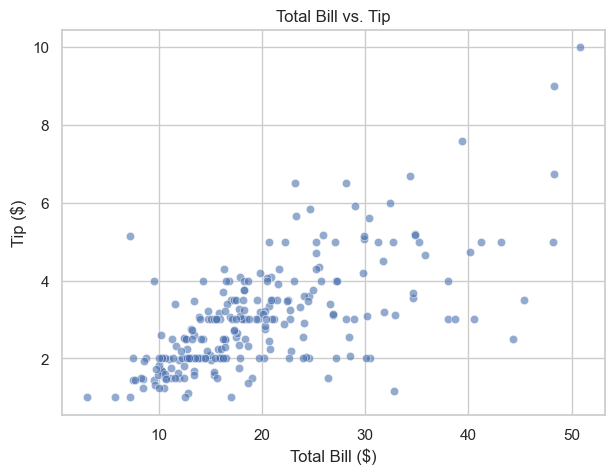

In [51]:
plt.figure(figsize=(7, 5))
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6, edgecolors='white', linewidth=0.5)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Total Bill vs. Tip')
plt.show()

Clear upward trend — as the bill increases, the tip tends to increase. The relationship looks roughly linear.

---
### 🎯 Your Turn

In [52]:
# YOUR CODE HERE
# Scatter plot of your X vs y — label your axes and add a title


**Answer these questions:**
1. Does there appear to be a linear relationship?
2. Is the relationship positive or negative?
3. Are there any obvious outliers?

*Your answers here:*

1. 
2. 
3. 

---
## A — Problem 3: Fit a Linear Regression Model

We use `sklearn`'s `LinearRegression` to find the best-fit line:

$$\hat{y} = \beta_0 + \beta_1 x$$

- $\beta_0$ — **intercept**: predicted y when x = 0  
- $\beta_1$ — **slope**: how much y changes for each 1-unit increase in x

---
### 📌 Example

In [53]:
X_tips = tips[['total_bill']]   # 2D — note the double brackets
y_tips = tips['tip']

model_a = LinearRegression()
model_a.fit(X_tips, y_tips)

print(f'Intercept (β₀): {model_a.intercept_:.4f}')
print(f'Slope     (β₁): {model_a.coef_[0]:.4f}')

Intercept (β₀): 0.9203
Slope     (β₁): 0.1050


Our model: $\hat{tip} = 0.9203 + 0.1050 \times total\_bill$  
For every extra dollar on the bill, the predicted tip increases by ~$0.11.

---
### 🎯 Your Turn

In [54]:
# Prepare X and y
# X_yours = df[['your_x_column']]
# y_yours = df['your_y_column']

# YOUR CODE HERE


# Fit the model and print intercept + slope


**Answer these questions:**
1. What is the slope? What does it mean in plain English?
2. What is the intercept? Does it make real-world sense?
3. Write out your model equation: ŷ = β₀ + β₁x

*Your answers here:*

1. 
2. 
3. 

---
## A — Problem 4: Plot the Regression Line & Evaluate with R²

**R²** tells us what proportion of the variation in y is explained by x.
- R² = 1.0 → perfect fit
- R² = 0.0 → model explains nothing
- R² = 0.5 → model explains 50% of the variation

---
### 📌 Example

R² = 0.4566


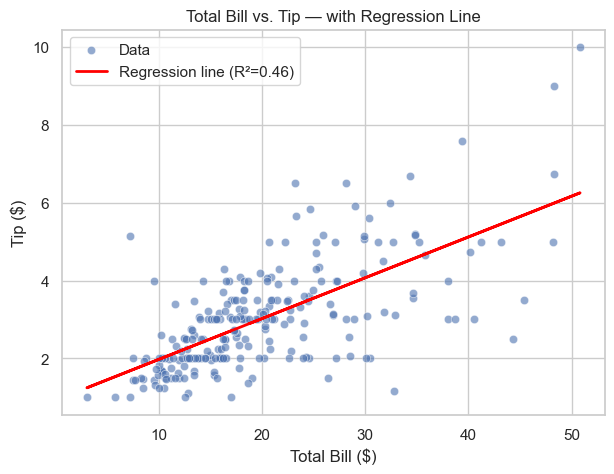

In [55]:
y_pred_tips = model_a.predict(X_tips)
r2 = r2_score(y_tips, y_pred_tips)
print(f'R² = {r2:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6, edgecolors='white', linewidth=0.5, label='Data')
plt.plot(tips['total_bill'], y_pred_tips, color='red', linewidth=2, label=f'Regression line (R²={r2:.2f})')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Total Bill vs. Tip — with Regression Line')
plt.legend()
plt.show()

R² ≈ 0.46 → the model explains about **46% of the variation** in tip amounts.

---
### 🎯 Your Turn

In [56]:
# YOUR CODE HERE
# 1. Generate predictions: y_pred_yours = your_model.predict(X_yours)
# 2. Calculate and print R²
# 3. Plot scatter + regression line


**Answer these questions:**
1. What is your R²? What percentage of variation does your model explain?
2. Is this a good, moderate, or poor fit? Why?
3. Does the regression line capture the trend in your scatter plot?

*Your answers here:*

1. 
2. 
3. 

---
## A — Problem 5: Residual Plot

A **residual** is the difference between actual and predicted: $\text{residual} = y - \hat{y}$

- ✅ **Good:** residuals scattered randomly around zero — no pattern
- ⚠️ **Problem:** a curve, a fan shape, or clusters — the linear model is missing something

---
### 📌 Example

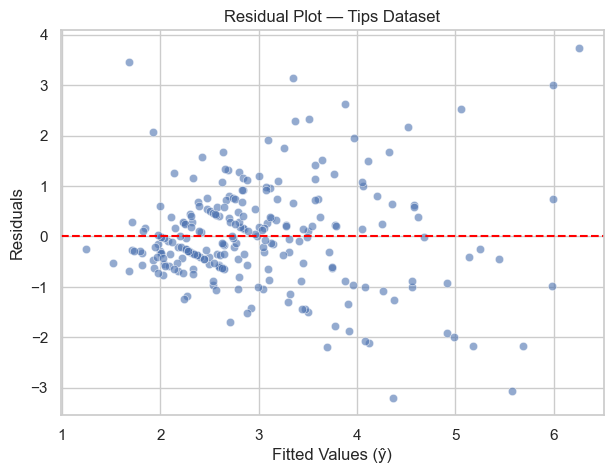

In [57]:
residuals_tips = y_tips - y_pred_tips

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_tips, residuals_tips, alpha=0.6, edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Fitted Values (ŷ)')
plt.ylabel('Residuals')
plt.title('Residual Plot — Tips Dataset')
plt.show()

The residuals fan out at higher fitted values (**heteroscedasticity**) — the model tends to underestimate tips for large bills.

---
### 🎯 Your Turn

In [58]:
# YOUR CODE HERE
# 1. Calculate residuals: residuals_yours = y_yours - y_pred_yours
# 2. Plot residuals vs fitted values
# 3. Add a horizontal dashed line at y=0


**Answer these questions:**
1. Are residuals randomly scattered around zero, or do you see a pattern?
2. Are there any unusually large residuals?
3. Does a linear model seem like a good choice for your data?

*Your answers here:*

1. 
2. 
3. 

---
---
# 🟠 TRACK B — Logistic Regression
### *Follow this track if your target variable is categorical (2 or more classes).*

> 💡 **Binary (2 classes) or Multinomial (3+ classes)?** The code is the same either way — sklearn detects the number of classes automatically. Where the interpretation differs, a note will flag it.
---
---

## B — Problem 1: Load & Explore Your Data

Same first step — understand your data before fitting anything.

---
### 📌 Example

We'll use the `penguins` dataset to predict **species** (3 classes) from **bill length**.

In [59]:
penguins = sns.load_dataset('penguins').dropna(subset=['bill_length_mm', 'species'])
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [60]:
print('Shape:', penguins.shape)
print()
print('Target classes and counts:')
print(penguins['species'].value_counts())

Shape: (342, 7)

Target classes and counts:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


We have **333 rows** and 3 species classes. We'll use:
- **X (independent):** `bill_length_mm`
- **y (dependent):** `species` — a categorical variable with 3 classes

---
### 🎯 Your Turn

In [61]:
# Load your dataset
# df = pd.read_csv('your_file.csv')

# YOUR CODE HERE


# Preview the first few rows


# Print shape and value counts for your target column


**Answer these questions:**
1. How many rows does your dataset have?
2. What is your X variable? What does it represent?
3. What is your y variable? How many categories does it have?
4. Are the classes roughly balanced, or is one category much more common?

*Your answers here:*

1. 
2. 
3. 
4. 

---
## B — Problem 2: Visualize the Relationship

With a categorical target, a **box plot** or **strip plot** works better than a scatter plot — it shows how the distribution of X differs across classes.

---
### 📌 Example

/var/folders/6t/bh97r6nj6tbf2hx8l0bckvdw0000gn/T/ipykernel_2573/2040817425.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x='species', y='bill_length_mm', palette='Set2')


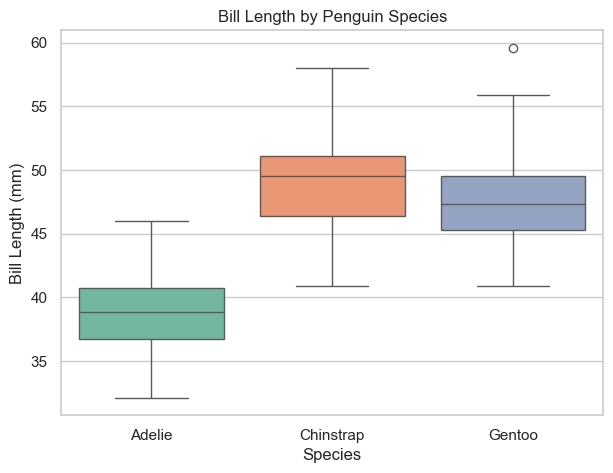

In [62]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=penguins, x='species', y='bill_length_mm', palette='Set2')
plt.xlabel('Species')
plt.ylabel('Bill Length (mm)')
plt.title('Bill Length by Penguin Species')
plt.show()

The distributions are clearly different across species — bill length looks like it carries useful signal for classification.

---
### 🎯 Your Turn

In [63]:
# YOUR CODE HERE
# Box plot: x = your categorical y column, y = your X column
# Label your axes and add a title


**Answer these questions:**
1. Do the distributions of X look different across categories?
2. Is there overlap between categories, or are they well separated?
3. Based on this plot, do you think X will be a useful predictor?

*Your answers here:*

1. 
2. 
3. 

---
## B — Problem 3: Fit a Logistic Regression Model

Logistic regression predicts the **probability** that an observation belongs to each class, then picks the most likely one.

The code pattern is identical to linear regression — just a different model class.

---
### 📌 Example

In [64]:
X_pen = penguins[['bill_length_mm']]   # 2D — note the double brackets
y_pen = penguins['species']

model_b = LogisticRegression(max_iter=1000)   # max_iter avoids convergence warnings
model_b.fit(X_pen, y_pen)

print('Classes:', model_b.classes_)
print()
# Show the coefficient for each class
for cls, coef in zip(model_b.classes_, model_b.coef_):
    print(f'  {cls}: coef = {coef[0]:.4f}')

Classes: ['Adelie' 'Chinstrap' 'Gentoo']

  Adelie: coef = -0.8047
  Chinstrap: coef = 0.4671
  Gentoo: coef = 0.3376


**How to read this:**  
A positive coefficient for a class means that a higher X value increases the model's confidence that the observation belongs to that class.

> 💡 **Binary vs. Multinomial:** With 2 classes sklearn shows one coefficient. With 3+ classes it shows one per class (as above). Same code either way.

---
### 🎯 Your Turn

In [65]:
# Prepare X and y
# X_yours = df[['your_x_column']]
# y_yours = df['your_y_column']

# YOUR CODE HERE


# Fit the model


# Print the classes and coefficients


**Answer these questions:**
1. How many classes did the model find?
2. Which class has the largest (most positive) coefficient? What does that mean?
3. In plain English: what is the model trying to predict?

*Your answers here:*

1. 
2. 
3. 

---
## B — Problem 4: Evaluate with Accuracy & Confusion Matrix

Instead of R², we evaluate classification models with:
- **Accuracy** — overall percentage of correct predictions
- **Confusion matrix** — shows exactly which classes are being confused with each other

---
### 📌 Example

Accuracy: 0.7573  (75.7% of predictions correct)



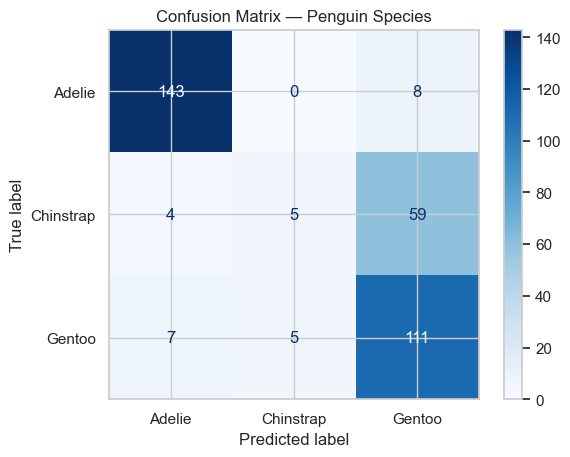

In [66]:
y_pred_pen = model_b.predict(X_pen)

acc = accuracy_score(y_pen, y_pred_pen)
print(f'Accuracy: {acc:.4f}  ({acc*100:.1f}% of predictions correct)\n')

# Confusion matrix
cm = confusion_matrix(y_pen, y_pred_pen, labels=model_b.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_b.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Penguin Species')
plt.show()

**How to read the confusion matrix:**  
- Each **row** is the actual class, each **column** is the predicted class.  
- Numbers on the **diagonal** = correct predictions.  
- Numbers **off the diagonal** = mistakes — and you can see *which* classes are being confused.

> 💡 **Binary models:** You'll also see terms like Precision and Recall. Run `print(classification_report(y_yours, y_pred_yours))` to get those automatically.

---
### 🎯 Your Turn

In [67]:
# YOUR CODE HERE
# 1. Generate predictions: y_pred_yours = your_model.predict(X_yours)
# 2. Calculate and print accuracy
# 3. Plot the confusion matrix


# Bonus: print the full classification report
# print(classification_report(y_yours, y_pred_yours))


**Answer these questions:**
1. What is your accuracy? Is this better than just always predicting the most common class?
2. Which classes does the model confuse most often?
3. Would you say this is a good, moderate, or poor fit? Why?

*Your answers here:*

1. 
2. 
3. 

---
## B — Problem 5: Predicted Probability Plot

Instead of a residual plot, we visualize how the model's **predicted probabilities** change as X increases. This is the logistic equivalent of plotting the regression line.

---
### 📌 Example

/var/folders/6t/bh97r6nj6tbf2hx8l0bckvdw0000gn/T/ipykernel_2573/2169723293.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_range = np.linspace(X_pen.min()[0], X_pen.max()[0], 300).reshape(-1, 1)
/Users/genesis/python_projects/virtual/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


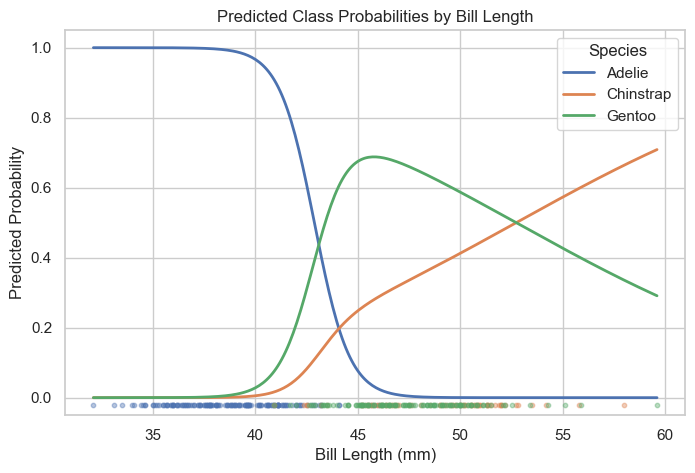

In [68]:
# Create a smooth range of X values for the probability curves
x_range = np.linspace(X_pen.min()[0], X_pen.max()[0], 300).reshape(-1, 1)
proba = model_b.predict_proba(x_range)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(model_b.classes_):
    plt.plot(x_range, proba[:, i], linewidth=2, label=cls)

# Overlay actual data as a rug plot
for i, cls in enumerate(model_b.classes_):
    mask = y_pen == cls
    plt.scatter(X_pen[mask], np.full(mask.sum(), -0.02), s=10, alpha=0.4)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Predicted Probability')
plt.title('Predicted Class Probabilities by Bill Length')
plt.legend(title='Species')
plt.ylim(-0.05, 1.05)
plt.show()

**What do we see?**  
Each curve shows the model's confidence that a penguin belongs to that species for a given bill length. Where curves overlap, the model is uncertain — those are the cases most likely to be misclassified.

> 💡 **Binary models:** You'll see two curves that mirror each other (they always sum to 1.0).

---
### 🎯 Your Turn

In [69]:
# YOUR CODE HERE
# 1. Create x_range using np.linspace over your X variable's range
# 2. Get predicted probabilities: proba = your_model.predict_proba(x_range)
# 3. Plot one curve per class
# 4. Label your axes and add a legend


**Answer these questions:**
1. At what value of X does the model switch from predicting one class to another?
2. Are there regions where the model is very uncertain (curves close together)?

*Your answers here:*

1. 
2. 